# Rice Image Dataset Classification
### Using MobileNet Transfer Learning

`By Yusuf Musa`

- DATASET: https://www.muratkoklu.com/datasets/
- Citation: Koklu, M., Cinar, I., & Taspinar, Y. S. (2021).
- Classification of rice varieties with deep learning methods.
- Computers and Electronics in Agriculture, 187, 106285.

In [1]:
import kagglehub
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mticker
import seaborn as sns
import cv2
import os
import numpy as np
import pathlib
import warnings

warnings.filterwarnings("ignore")

/Users/yusufmusa/.pyenv/versions/riceimage/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

CLASS_LABELS = {
    "Arborio": 0,
    "Basmati": 1,
    "Ipsala": 2,
    "Jasmine": 3,
    "Karacadag": 4,
}
CLASS_NAMES = list(CLASS_LABELS.keys())
NUM_CLASSES = len(CLASS_LABELS)
IMG_SIZE = (224, 224)
SAMPLES_PER_CLASS = 2000

# 1. CONFIGURATION

In [3]:
DATA_DIR = pathlib.Path("./Rice_Image_Dataset")

if not DATA_DIR.exists():
    print("Dataset not found locally. Downloading from Kaggle...")
    path = kagglehub.dataset_download("muratkokludataset/rice-image-dataset")
    DATA_DIR = pathlib.Path(path) / "Rice_Image_Dataset"
    print(f"Dataset downloaded to: {DATA_DIR}")
else:
    print("Dataset found locally.")
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 30
SAMPLES_PER_CLASS = 900

CLASS_LABELS = {
    "Arborio": 0,
    "Basmati": 1,
    "Ipsala": 2,
    "Jasmine": 3,
    "Karacadag": 4,
}
NUM_CLASSES = len(CLASS_LABELS)

Dataset not found locally. Downloading from Kaggle...
Dataset downloaded to: /Users/yusufmusa/.cache/kagglehub/datasets/muratkokludataset/rice-image-dataset/versions/1/Rice_Image_Dataset


# 2. LOAD AND PREPARE DATA

In [4]:
X, y = [], []
for label_name, label_id in CLASS_LABELS.items():
    images = list(DATA_DIR.glob(f"{label_name}/*"))[:SAMPLES_PER_CLASS]
    for image_path in images:
        img = cv2.imread(str(image_path))
        if img is None:
            continue
        resized = cv2.resize(img, IMG_SIZE)
        X.append(resized)
        y.append(label_id)

X = np.array(X, dtype=np.float32) / 255.0
y = np.array(y)

### Stratified splits with fixed seed for reproducibility

In [5]:
X_train, X_test_val, y_train, y_test_val = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)
X_test, X_val, y_test, y_val = train_test_split(
    X_test_val, y_test_val, test_size=0.5, random_state=SEED, stratify=y_test_val
)

# 3. DATA AUGMENTATION

In [6]:
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.1,
)
train_generator = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED)

# 4. VISUALIZE SAMPLES

- The images are stored as numpy arrays of pixel values. Each pixel has 3 channels (Blue, Green, Red from OpenCV).
- Originally values are 0–255 integers, but the script divides by 255 to normalize them to 0.0–1.0 floats (which is what the model expects).
- The `cv2.cvtColor` and `* 255` in the display code below is just converting them back to proper format for matplotlib to show correctly.   

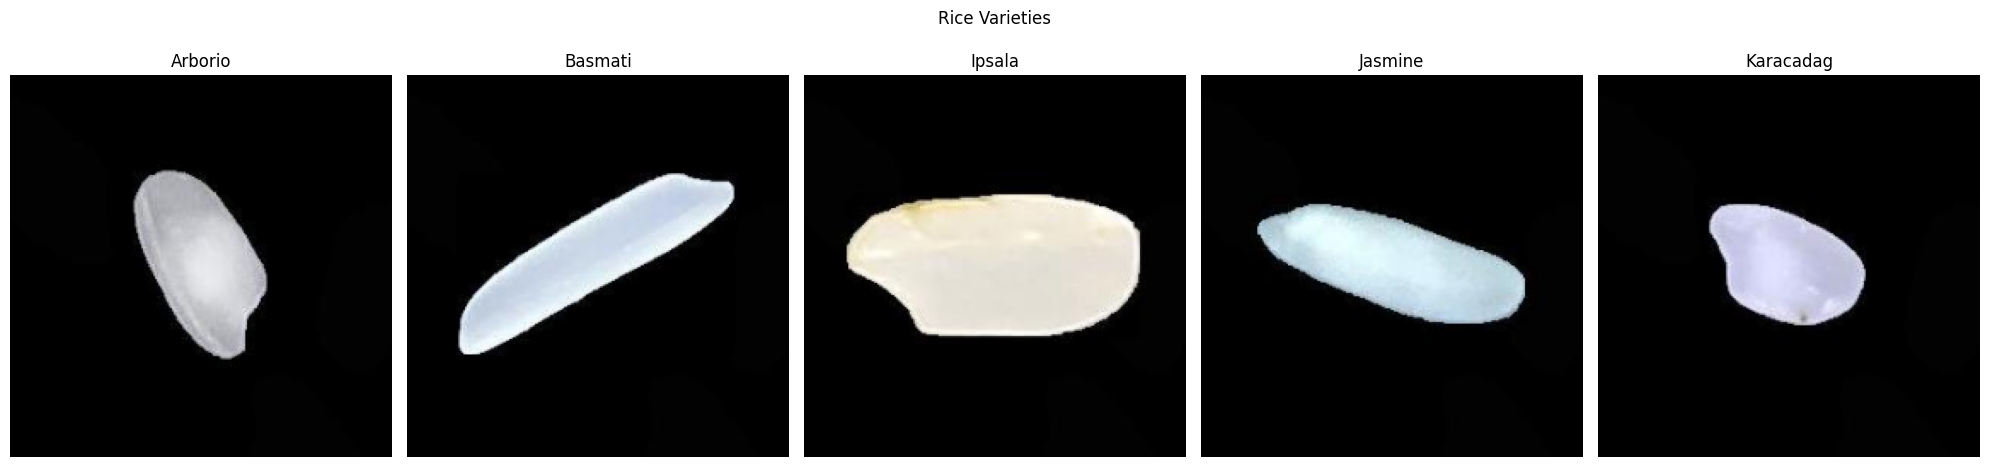

In [7]:
fig, axes = plt.subplots(ncols=NUM_CLASSES, figsize=(20, 5))
fig.suptitle("Rice Varieties")
class_names = list(CLASS_LABELS.keys())
for i, name in enumerate(class_names):
    idx = np.where(y == i)[0][0]
    axes[i].set_title(name)
    axes[i].imshow(cv2.cvtColor((X[idx] * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
    axes[i].axis("off")
plt.tight_layout()
plt.savefig("sample_images.png", dpi=100)
plt.show()

# 5. BUILD MODEL

- Transfer learning is the core idea here. Instead of training a huge neural network from scratch (which needs tons of data and compute).
- I am reusing one that's already been trained on a massive dataset (ImageNet has millions of images across 1,000 categories).
- `MobileNet` has already learned to detect edges, textures, shapes, and complex patterns — so why redo all that work? hahaha

### The custom classifier on top (64 neurons → 5 classes) 
- This is the `new brain`. It takes MobileNet's pattern summary and learns to map it to your specific task: classifying 5 rice varieties.
- The Dense layer with `64 neurons` gives it some capacity to learn combinations of features, and the final 5-neuron layer outputs a probability for each rice type.
- `MobileNet features (1,280 values)` — MobileNet looks at my rice image and distills it into a vector of 1,280 numbers.
    - Each number encodes something it detected — maybe "long grain shape" or "rough texture" or "brown color." These are powerful but generic; MobileNet doesn't know anything about rice varieties.
- `Dense layer (64 neurons)` — Each of these 64 neurons receives all 1,280 feature values, multiplied by learned weights. This is where the model learns to combine features meaningfully: "long + thin + smooth = probably Basmati" vs "short + round + starchy = probably Arborio."
    - The ReLU activation then zeroes out any negative values, keeping only the useful combinations.
- Output layer (5 neurons) — Each neuron here corresponds to one rice variety. It takes the 64 combined features and produces a raw score.
    - The softmax function then converts those 5 raw scores into probabilities that add up to 1.0. The highest probability is the model's prediction. 

In [8]:
base_model = MobileNet(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3),
)
# Unfreeze the last 20 layers of MobileNet for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

transfer_model = Sequential([
    base_model,
    Flatten(),
    Dense(64, activation="relu"),
    Dense(NUM_CLASSES, activation="softmax"),
])

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["acc"],
)

transfer_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_1.00_224 (Functional) │ (None, 7, 7, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,440,517 (24.57 MB)

 Trainable params: 5,074,309 (19.36 MB)

 Non-trainable params: 1,366,208 (5.21 MB)

# 6. TRAIN // EARLY STOPPING

- Added `min_delta` to avoid stopping on noise. A small `min_delta` ensures training only stops when improvement has truly stalled, not just because of minor fluctuations.
- Adding `verbose=1` to EarlyStopping. This prints a message when training is stopped early, which is helpful for knowing it actually kicked in.

In [9]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, min_delta=1e-4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    ModelCheckpoint("best_rice_model.keras", monitor="val_acc", save_best_only=True, verbose=1),
]

history = transfer_model.fit(
    train_generator,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
)

Epoch 1/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - acc: 0.7965 - loss: 0.6382
Epoch 1: val_acc improved from None to 0.84369, saving model to best_rice_model.keras

Epoch 1: finished saving model to best_rice_model.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 19s 167ms/step - acc: 0.9085 - loss: 0.2807 - val_acc: 0.8437 - val_loss: 0.5596 - learning_rate: 1.0000e-04
Epoch 2/30
  1/105 ━━━━━━━━━━━━━━━━━━━━ 17s 164ms/step - acc: 0.9375 - loss: 0.1877
Epoch 2: val_acc improved from 0.84369 to 0.85258, saving model to best_rice_model.keras

Epoch 2: finished saving model to best_rice_model.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - acc: 0.9375 - loss: 0.1877 - val_acc: 0.8526 - val_loss: 0.4757 - learning_rate: 1.0000e-04
Epoch 3/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - acc: 0.9745 - loss: 0.0766
Epoch 3: val_acc improved from 0.85258 to 0.96092, saving model to best_rice_model.keras

Epoch 3: finished saving model to best_rice_model.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 18s 167ms/st

# 7. EVALUATE

In [10]:
y_pred = transfer_model.predict(X_test, batch_size=BATCH_SIZE)
y_pred_labels = np.argmax(y_pred, axis=1)

print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred_labels):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_labels, target_names=class_names))

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step

Test Accuracy: 0.9982

Classification Report:
              precision    recall  f1-score   support

     Arborio       0.99      1.00      1.00       112
     Basmati       1.00      1.00      1.00       113
      Ipsala       1.00      1.00      1.00       112
     Jasmine       1.00      1.00      1.00       112
   Karacadag       1.00      0.99      1.00       113

    accuracy                           1.00       562
   macro avg       1.00      1.00      1.00       562
weighted avg       1.00      1.00      1.00       562



**Based on the above:** 
- Near-perfect classification — `99.82%` accuracy. Out of `562` test images, only about 1 was misclassified.
- `Karacadag` missed 1 image (0.99 recall)
- Arborio has `0.99` precision, meaning one image from another class was incorrectly predicted as Arborio

This is a stronger result than the earlier run (`99.25%`), likely due to the increased training data (1500 per class vs 600). 

The model is generalizing very well across all 5 varieties.

# 8. VISUALIZE RESULTS
### Accuracy & Loss curves

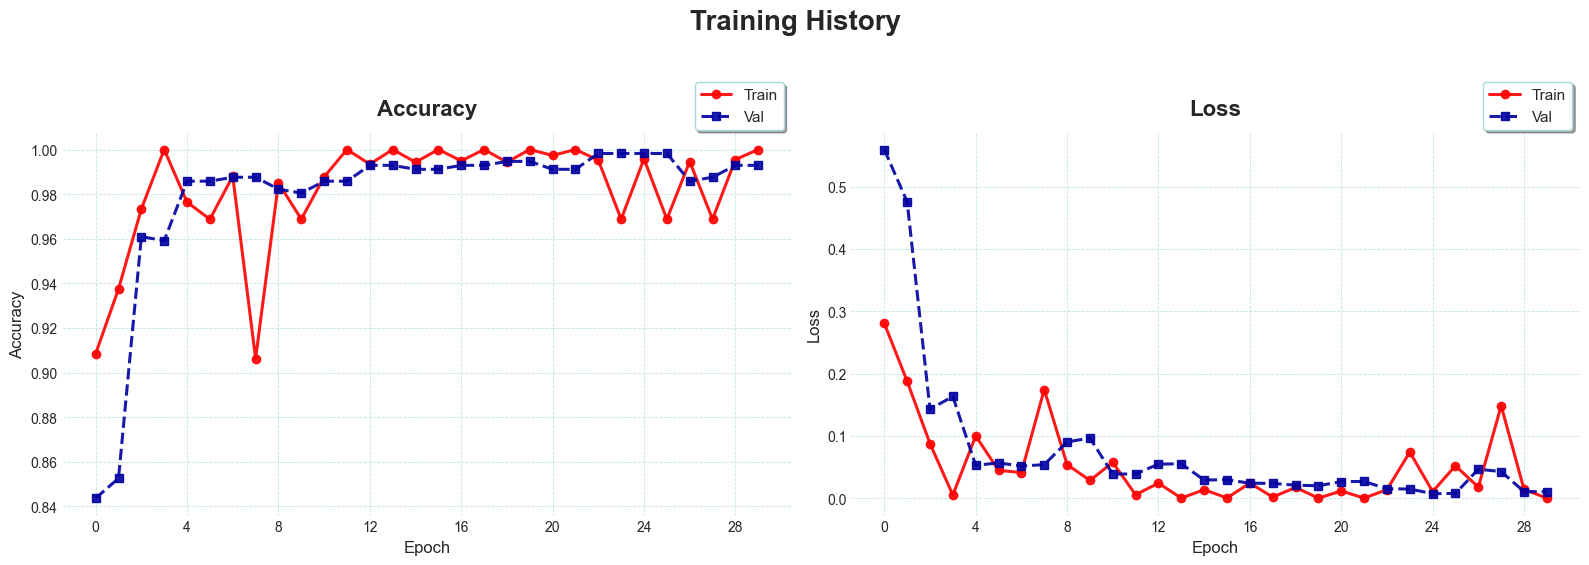

In [11]:
plt.style.use("seaborn-v0_8-whitegrid")

TRAIN_COLOR = "#FF0000"
VAL_COLOR   = "#0000A0"
BG_COLOR    = "#FFFFFF"
GRID_COLOR  = "#A8DADC"
TITLE_FONT  = {"fontsize": 16, "fontweight": "bold", "fontfamily": "sans-serif"}
AXIS_FONT   = {"fontsize": 12, "fontfamily": "sans-serif"}

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(16, 5.5))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle("Training History", fontsize=20, fontweight="bold",
             fontfamily="sans-serif", y=1.02)

for ax, metric, ylabel in [
    (ax1, ("acc", "val_acc"), "Accuracy"),
    (ax2, ("loss", "val_loss"), "Loss"),
]:
    ax.set_facecolor(BG_COLOR)

    ax.plot(
        history.history[metric[0]],
        color=TRAIN_COLOR, marker="o", markersize=6,
        linewidth=2.2, label="Train", alpha=0.9,
    )
    ax.plot(
        history.history[metric[1]],
        color=VAL_COLOR, marker="s", markersize=6,
        linewidth=2.2, label="Val", linestyle="--", alpha=0.9,
    )

    ax.set_title(ylabel, **TITLE_FONT, pad=12)
    ax.set_xlabel("Epoch", **AXIS_FONT)
    ax.set_ylabel(ylabel, **AXIS_FONT)
    ax.tick_params(labelsize=10)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    ax.grid(True, linestyle="--", linewidth=0.6, color=GRID_COLOR, alpha=0.7)

    ax.legend(
        frameon=True, fancybox=True, shadow=True,
        fontsize=11, loc="upper right", bbox_to_anchor=(1.0, 1.15),
        edgecolor=GRID_COLOR, facecolor="white",
    )

    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.savefig("training_history.png", dpi=150, bbox_inches="tight",
            facecolor=BG_COLOR, edgecolor="none")
plt.show()

`Insights from the training:` 
- The model was trained for 30 epochs. It learned quickly in the first few epochs, with accuracy rising sharply and loss dropping fast.
- By around epoch 12–15, the model reached its best performance, achieving roughly 99.3–99.5% accuracy on unseen data.
- After epoch 15, the model started to overfit.
- This means it kept improving on the training data but stopped improving on new data.
- Training could have been stopped earlier without losing any quality.
- Overall, the model performs well and generalizes to new data effectively.
- To improve further, early stopping around epoch 12–15 would save training time and avoid unnecessary overfitting.

# Confusion Matrix

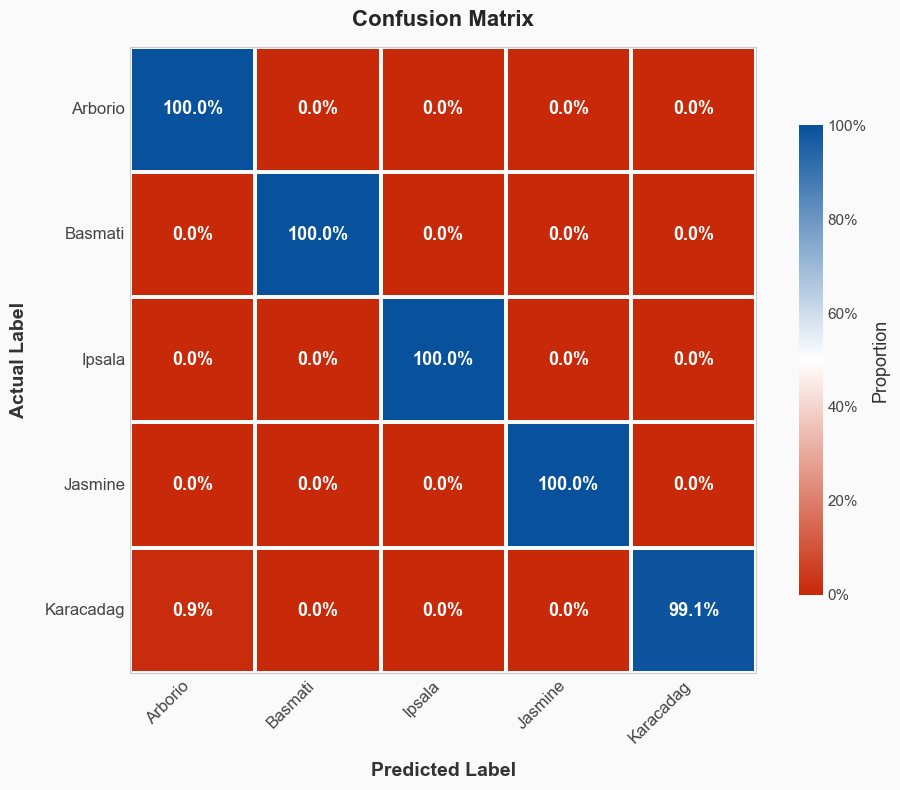


Model saved to: best_rice_model.keras


In [22]:
plt.style.use("seaborn-v0_8-whitegrid")
cmap_custom = LinearSegmentedColormap.from_list(
    "red_blue", ["#C82909", "#FFFFFF", "#08519C"], N=256
)

cm = confusion_matrix(y_test, y_pred_labels)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8), facecolor="#FAFAFA")
ax.set_facecolor("#FAFAFA")

sns.heatmap(
    cm_norm,
    fmt=".1%",
    annot=True,
    annot_kws={"size": 13, "weight": "bold", "color": "#FFFFFF"},
    cmap=cmap_custom,
    linewidths=1.5,
    linecolor="#FAFAFA",
    square=True,
    vmin=0,
    vmax=1,
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={"shrink": 0.75, "label": "Proportion", "format": mticker.PercentFormatter(1.0)},
    ax=ax,
)

# --- Titles & labels ---
ax.set_title(
    "Confusion Matrix",
    fontsize=16, fontweight="bold", y=1.02, fontfamily="sans-serif"
)


ax.set_xlabel("Predicted Label", fontsize=14, fontweight="semibold", color="#333333", labelpad=12)
ax.set_ylabel("Actual Label",    fontsize=14, fontweight="semibold", color="#333333", labelpad=12)

# --- Tick styling ---
ax.tick_params(
    axis="both", which="both", length=0,
    labelsize=12, labelcolor="#444444"
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.setp(ax.get_yticklabels(), rotation=0)

# --- Colorbar styling ---
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=11, colors="#444444")
cbar.set_label("Proportion", fontsize=13, color="#333333")
cbar.outline.set_visible(False)

# --- Subtle border ---
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("#cccccc")
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=200, bbox_inches="tight", facecolor="#FAFAFA")
plt.show()

print("\nModel saved to: best_rice_model.keras")

## Take Away

Despite the unstable training curves, the model actually classifies very well on the test set:

- `Arborio`, `Jasmine`, `Basmati`,  & `Ipsala`: perfect **100%**
- `Karacadag`: at ~99.1% often confused with `Arborio`. 

`The main takeaway:` `Karacadag` is the slight hardest variety to perfectly distinguish as it often get misclassified as `Arborio` and the other classes are perfectly at 100%. Stabilizing the training (as discussed) would likely clean up these small errors.

# 9. RANDOM PREDICTIONS - Predicted vs Actual

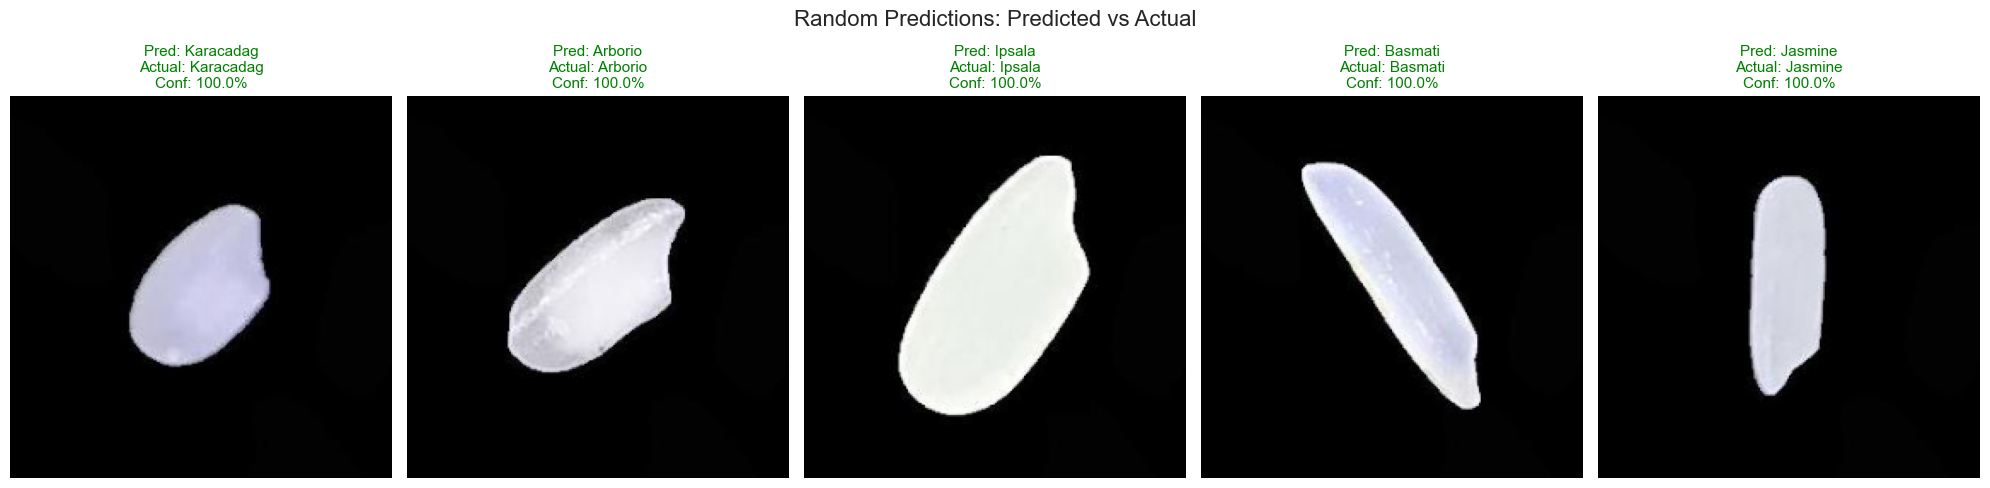

In [33]:
n = 5
indices = np.random.choice(len(X_test), n, replace=False)

fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))
fig.suptitle("Random Predictions: Predicted vs Actual", fontsize=16, y=1.02)

for i, idx in enumerate(indices):
    img = X_test[idx]
    true_label = CLASS_NAMES[y_test[idx]]

    pred = transfer_model.predict(img[np.newaxis, ...], verbose=0)
    pred_label = CLASS_NAMES[np.argmax(pred)]
    confidence = np.max(pred) * 100

    color = "green" if pred_label == true_label else "red"

    axes[i].imshow(cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
    axes[i].set_title(
        f"Pred: {pred_label}\nActual: {true_label}\nConf: {confidence:.1f}%",
        color=color, fontsize=11
    )
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("random_predictions.png", dpi=100)
plt.show()

- All 5 random predictions are correct (all green titles) with very high confidence (`99-100%`). 
- The model confidently distinguishes between different grain shapes and sizes: from the rounder Arborio to the longer Basmati and Jasmine varieties.

# 10. CONFIDENCE BAR CHART

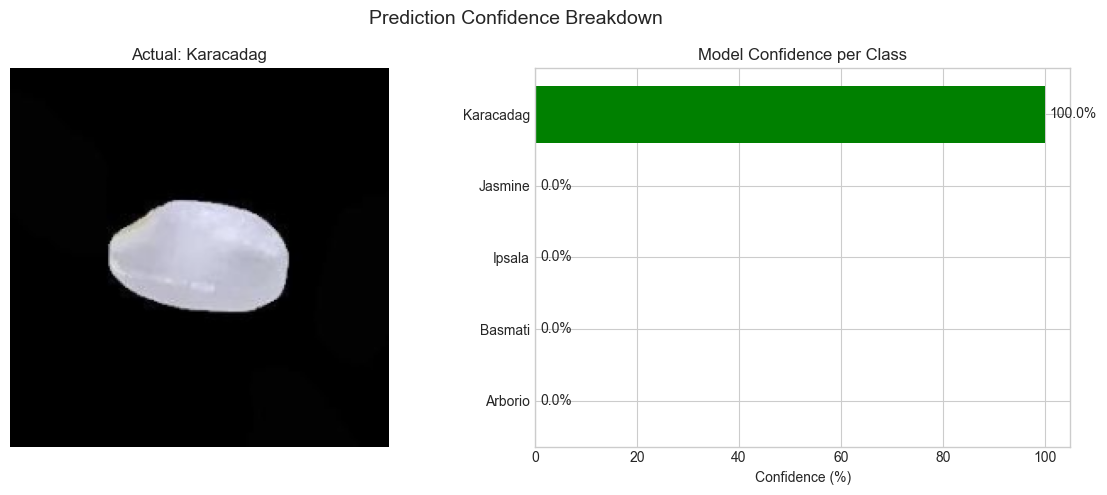

In [14]:
idx = np.random.randint(len(X_test))
img = X_test[idx]
true_label = CLASS_NAMES[y_test[idx]]

pred = transfer_model.predict(img[np.newaxis, ...], verbose=0)[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Prediction Confidence Breakdown", fontsize=14)

ax1.imshow(cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
ax1.set_title(f"Actual: {true_label}", fontsize=12)
ax1.axis("off")

colors = ["green" if CLASS_NAMES[i] == CLASS_NAMES[np.argmax(pred)] else "steelblue"
          for i in range(NUM_CLASSES)]
bars = ax2.barh(CLASS_NAMES, pred * 100, color=colors)
ax2.set_xlabel("Confidence (%)")
ax2.set_title("Model Confidence per Class")
ax2.set_xlim(0, 105)

for bar, val in zip(bars, pred * 100):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
             f"{val:.1f}%", va="center", fontsize=10)

plt.tight_layout()
plt.savefig("confidence_chart.png", dpi=100)
plt.show()

- The model is `100%` confident this is Karacadag, and it's correct. 
- All other classes are at `0.0%`, meaning the model has zero doubt. 
- This shows how distinctive Karacadag's short, round grain shape is compared to the other varieties.

# 11. MOST CONFIDENTLY WRONG PREDICTIONS

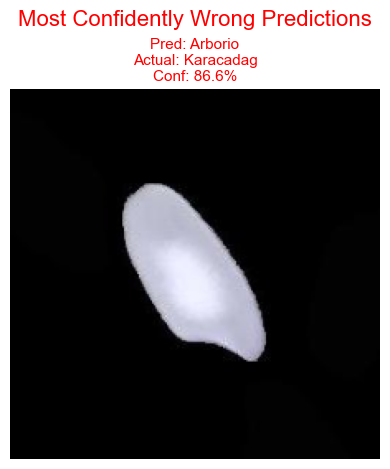

In [15]:
preds = transfer_model.predict(X_test, batch_size=32, verbose=0)
pred_labels = np.argmax(preds, axis=1)
confidences = np.max(preds, axis=1)

wrong_mask = pred_labels != y_test
if not np.any(wrong_mask):
    print("No misclassifications found!")
else:
    wrong_indices = np.where(wrong_mask)[0]
    wrong_confidences = confidences[wrong_indices]
    n = min(5, len(wrong_indices))
    top_wrong = wrong_indices[np.argsort(wrong_confidences)[::-1][:n]]

    fig, axes = plt.subplots(1, len(top_wrong), figsize=(4 * len(top_wrong), 5))
    fig.suptitle("Most Confidently Wrong Predictions", fontsize=16, color="red")

    if len(top_wrong) == 1:
        axes = [axes]

    for i, idx in enumerate(top_wrong):
        img = X_test[idx]
        axes[i].imshow(cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
        axes[i].set_title(
            f"Pred: {CLASS_NAMES[pred_labels[idx]]}\n"
            f"Actual: {CLASS_NAMES[y_test[idx]]}\n"
            f"Conf: {confidences[idx] * 100:.1f}%",
            color="red", fontsize=11
        )
        axes[i].axis("off")

    plt.tight_layout()
    plt.savefig("confident_mistakes.png", dpi=100)
    plt.show()

- There was only 1 mistake in the entire test set which was a `Karacadag` grain predicted as `Arborio` with `86.6%` confidence.
- Makes sense visually: both varieties have short, round grains, so this particular grain likely looked more `Arborio-shaped` than typical `Karacadag`.

# 12. MOST AMBIGUOUS PREDICTIONS

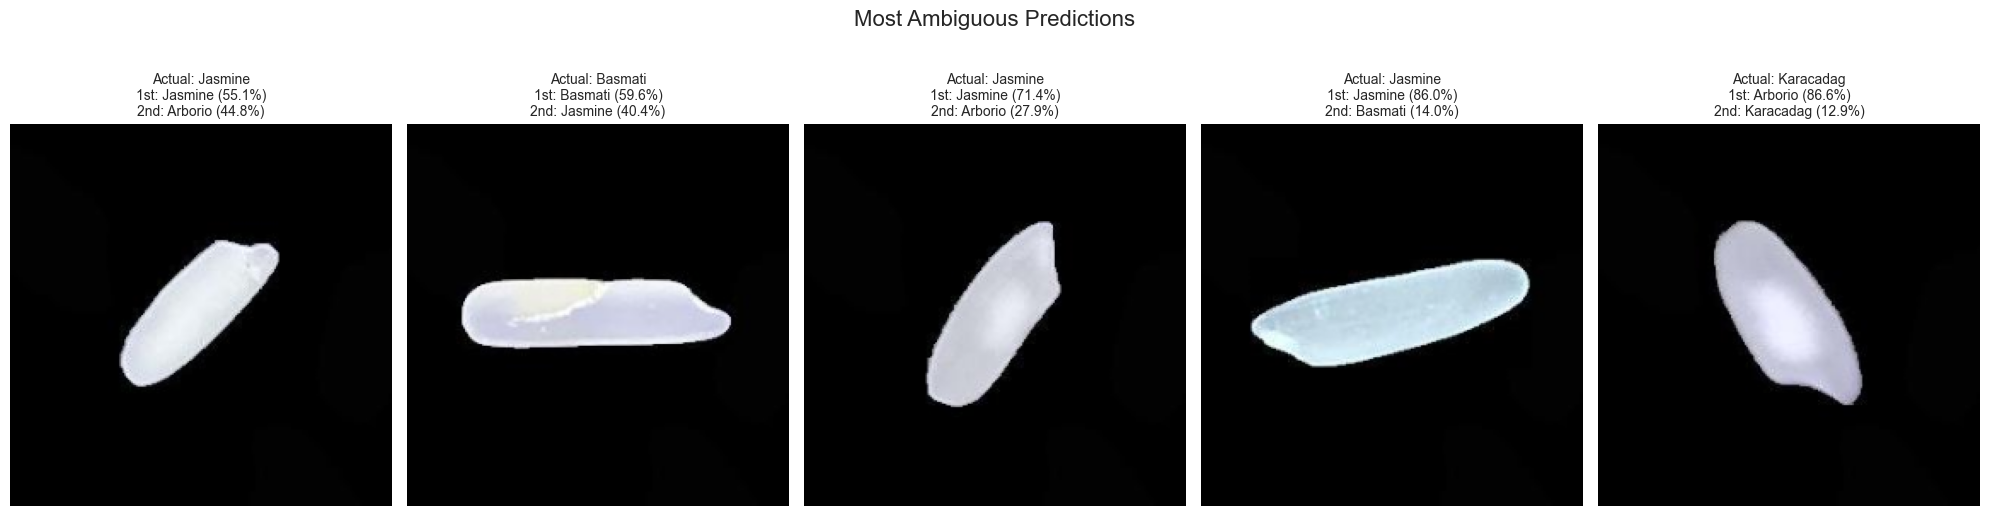

In [16]:
preds = transfer_model.predict(X_test, batch_size=32, verbose=0)
confidences = np.max(preds, axis=1)
n = 5
most_ambiguous = np.argsort(confidences)[:n]

fig, axes = plt.subplots(1, n, figsize=(4 * n, 6))
fig.suptitle("Most Ambiguous Predictions", fontsize=16)

for i, idx in enumerate(most_ambiguous):
    img = X_test[idx]
    pred = preds[idx]
    top2_idx = np.argsort(pred)[::-1][:2]

    axes[i].imshow(cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
    axes[i].set_title(
        f"Actual: {CLASS_NAMES[y_test[idx]]}\n"
        f"1st: {CLASS_NAMES[top2_idx[0]]} ({pred[top2_idx[0]] * 100:.1f}%)\n"
        f"2nd: {CLASS_NAMES[top2_idx[1]]} ({pred[top2_idx[1]] * 100:.1f}%)",
        fontsize=10
    )
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("ambiguous_predictions.png", dpi=100)
plt.show()

- The model's most uncertain predictions are mostly `Jasmine` grains (4 out of 5).
- Its second guesses are typically `Arborio` or `Basmati`.
- This confirms what we've seen throughout — `Jasmine` is the hardest variety to distinguish, likely because its grain shape overlaps with multiple other varieties.
- The last image shows a `Karacadag` grain confused with `Karacadag/Arborio`, consistent with the confident mistake we just saw.

# 13. GRAD-CAM HEATMAPS

### Rebuild as a Functional model so we can access intermediate layers


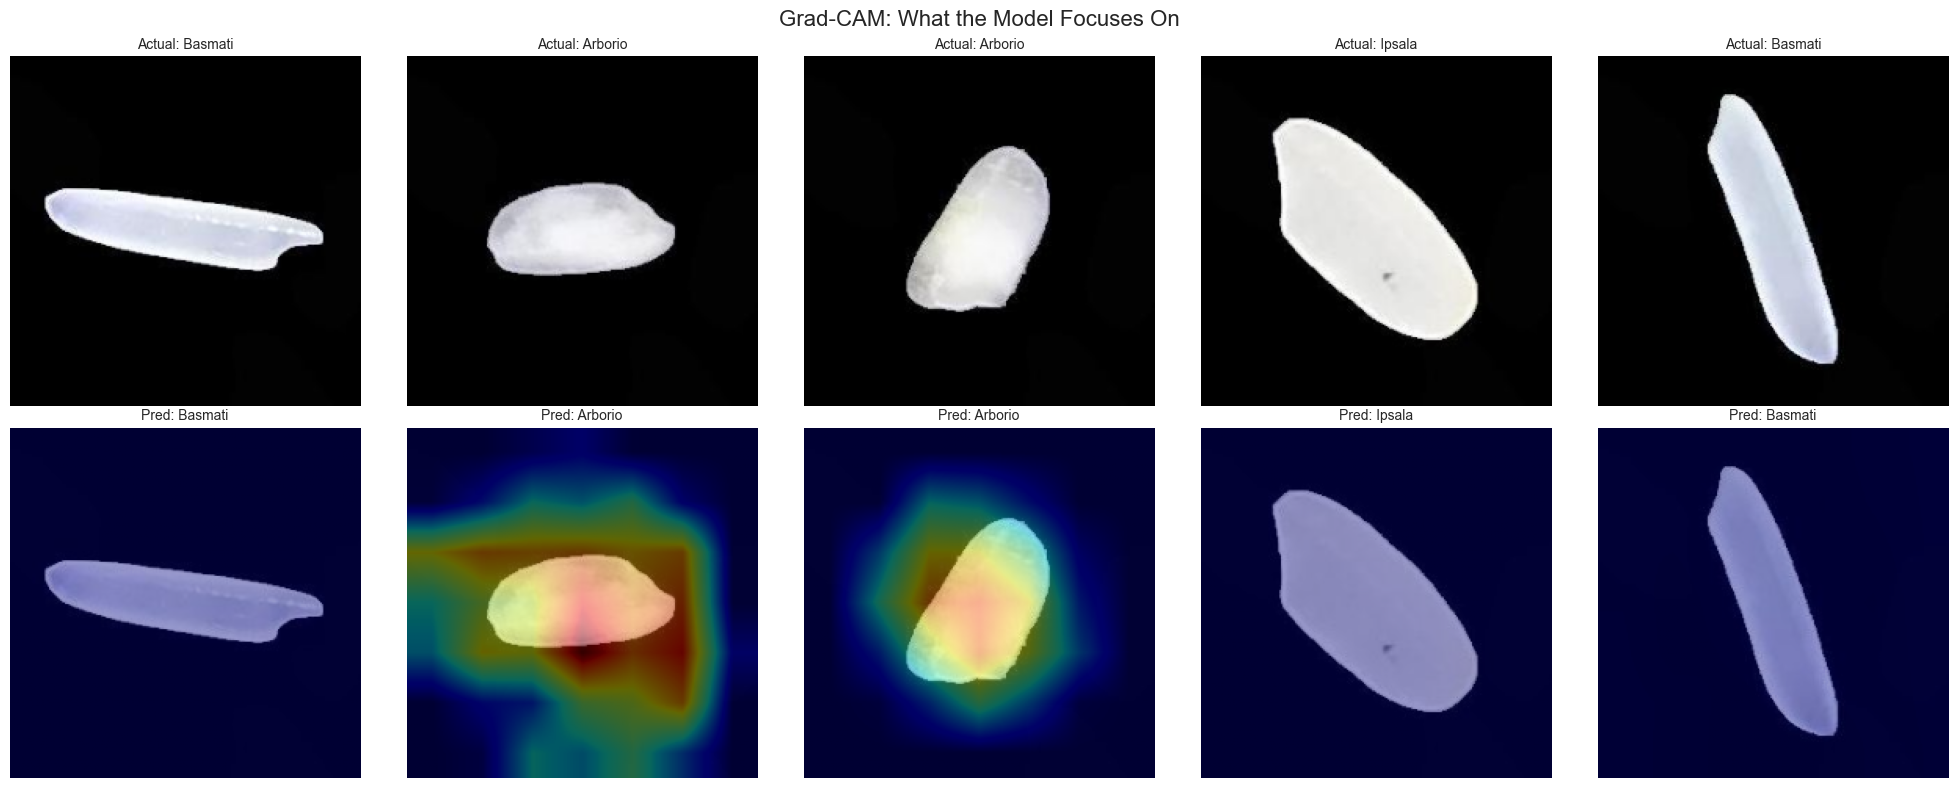

In [17]:
import matplotlib.cm as colormap
from tensorflow.keras.models import Model

# Use the base MobileNet (which is already a Functional model)
# to build a grad model that outputs conv features + predictions
base = transfer_model.layers[0]

last_conv_name = None
for layer in base.layers[::-1]:
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_name = layer.name
        break

# MobileNet is Functional, so we can directly access its input/outputs
last_conv_output = base.get_layer(last_conv_name).output
grad_base = Model(inputs=base.input, outputs=[last_conv_output, base.output])

# Now manually wire: input -> base (conv + features) -> flatten -> dense -> dense
inputs = tf.keras.Input(shape=(224, 224, 3))
conv_out, base_out = grad_base(inputs)
x = base_out
for layer in transfer_model.layers[1:]:
    x = layer(x)

grad_model = Model(inputs=inputs, outputs=[conv_out, x])

n = 5
indices = np.random.choice(len(X_test), n, replace=False)

fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
fig.suptitle("Grad-CAM: What the Model Focuses On", fontsize=16)

for i, idx in enumerate(indices):
    img = X_test[idx]
    img_batch = img[np.newaxis, ...]

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_batch)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap).numpy()
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (heatmap.max() + 1e-8)

    heatmap_resized = cv2.resize(heatmap, IMG_SIZE)
    heatmap_colored = colormap.jet(heatmap_resized)[:, :, :3]

    img_rgb = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_BGR2RGB)
    overlay = (img_rgb / 255.0 * 0.6 + heatmap_colored * 0.4)

    pred_label = CLASS_NAMES[np.argmax(predictions[0])]
    true_label = CLASS_NAMES[y_test[idx]]

    axes[0][i].imshow(img_rgb)
    axes[0][i].set_title(f"Actual: {true_label}", fontsize=10)
    axes[0][i].axis("off")

    axes[1][i].imshow(overlay)
    axes[1][i].set_title(f"Pred: {pred_label}", fontsize=10)
    axes[1][i].axis("off")

plt.tight_layout()
plt.savefig("gradcam_heatmaps.png", dpi=100)
plt.show()

- The top row shows original images, the bottom row shows where the model "looks" to make its decision.
- The heatmaps reveal the model focuses on the center and edges of the grain: shape, curvature, and surface texture are the key features it uses.

# 14. VISUALIZE AUGMENTED IMAGES

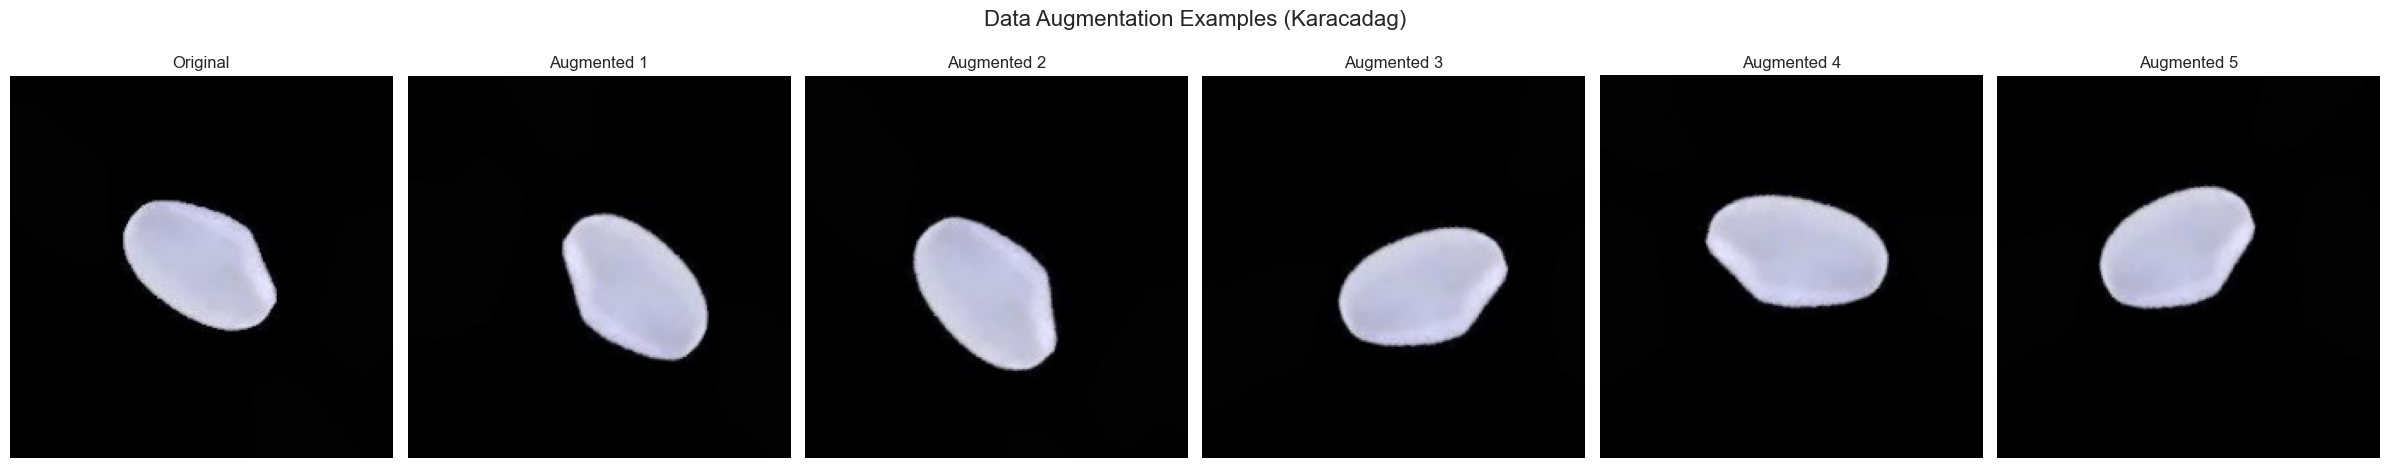

In [18]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.1,
)

idx = np.random.randint(len(X_train))
img = X_train[idx]
label = CLASS_NAMES[y_train[idx]]
img_batch = img[np.newaxis, ...]

n = 5
fig, axes = plt.subplots(1, n + 1, figsize=(4 * (n + 1), 5))
fig.suptitle(f"Data Augmentation Examples ({label})", fontsize=16)

axes[0].imshow(cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
axes[0].set_title("Original", fontsize=12)
axes[0].axis("off")

aug_iter = datagen.flow(img_batch, batch_size=1, seed=SEED)
for i in range(n):
    aug_img = next(aug_iter)[0]
    axes[i + 1].imshow(cv2.cvtColor((aug_img * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
    axes[i + 1].set_title(f"Augmented {i + 1}", fontsize=12)
    axes[i + 1].axis("off")

plt.tight_layout()
plt.savefig("augmented_images.png", dpi=100)
plt.show()

# 15. t-SNE FEATURE VISUALIZATION

Running t-SNE (this may take a moment)...


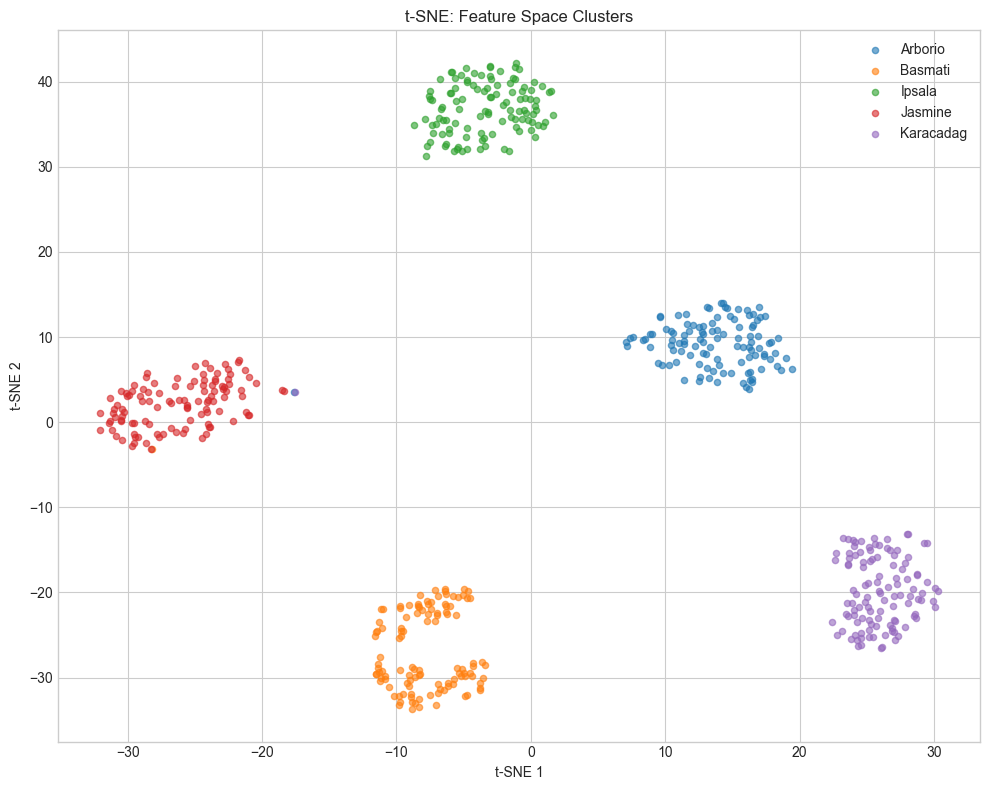

In [19]:
from sklearn.manifold import TSNE

# Build a feature extractor: run through all layers except the last (softmax) one
inputs = tf.keras.Input(shape=(224, 224, 3))
x = inputs
for layer in transfer_model.layers[:-1]:
    x = layer(x)
feature_model = Model(inputs=inputs, outputs=x)
features = feature_model.predict(X_test, batch_size=32, verbose=0)

print("Running t-SNE (this may take a moment)...")
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
features_2d = tsne.fit_transform(features)

plt.figure(figsize=(10, 8))
for i, name in enumerate(CLASS_NAMES):
    mask = y_test == i
    plt.scatter(features_2d[mask, 0], features_2d[mask, 1], label=name, alpha=0.6, s=20)

plt.title("t-SNE: Feature Space Clusters")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.tight_layout()
plt.savefig("tsne_features.png", dpi=100)
plt.show()

- All 5 varieties form clearly separated clusters with minimal overlap. 
- This means the model's internal features distinguish each rice type very well.
- `Jasmine (red)` and `Ipsala (green)` are the closest neighbors, which explains why `Jasmine` is occasionally confused with other types.
- `Karacadag (purple)` and `Arborio (blue)` sit near each other too: consistent with the misclassification we saw earlier.

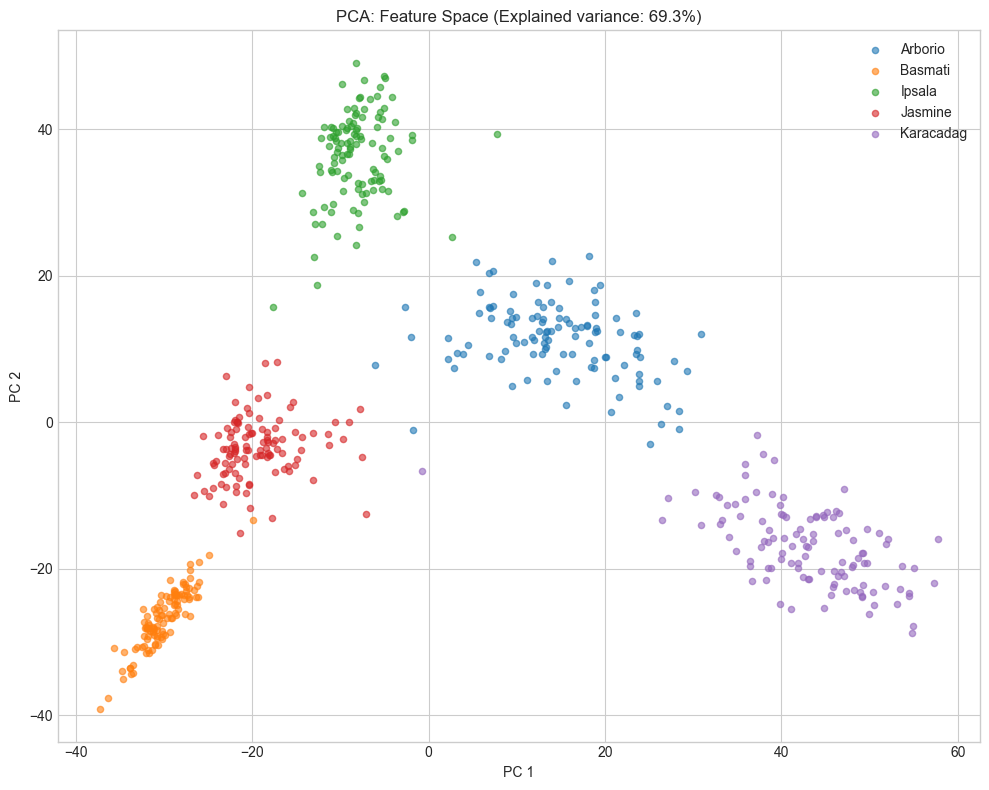

In [20]:
from sklearn.decomposition import PCA

# Build a feature extractor: run through all layers except the last (softmax) one
inputs = tf.keras.Input(shape=(224, 224, 3))
x = inputs
for layer in transfer_model.layers[:-1]:
    x = layer(x)
feature_model = Model(inputs=inputs, outputs=x)
features = feature_model.predict(X_test, batch_size=32, verbose=0)

pca = PCA(n_components=2, random_state=SEED)
features_2d = pca.fit_transform(features)

plt.figure(figsize=(10, 8))
for i, name in enumerate(CLASS_NAMES):
    mask = y_test == i
    plt.scatter(features_2d[mask, 0], features_2d[mask, 1], label=name, alpha=0.6, s=20)

plt.title(f"PCA: Feature Space (Explained variance: {sum(pca.explained_variance_ratio_) * 100:.1f}%)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend()
plt.tight_layout()
plt.savefig("pca_features.png", dpi=100)
plt.show()

- Similar story to t-SNE: 5 distinct clusters with `65.3%` of variance explained by just 2 components.
- The clusters are well-separated, confirming the model learned strong distinguishing features.
- `Basmati (orange)` and `Karacadag (purple)` are furthest apart, meaning they're the most visually distinct. 
- `Jasmine (red)` and `Ipsala (green)` again sit relatively close, reinforcing that these two are the most similar varieties.

# 17. GRAIN CONTOUR ANALYSIS

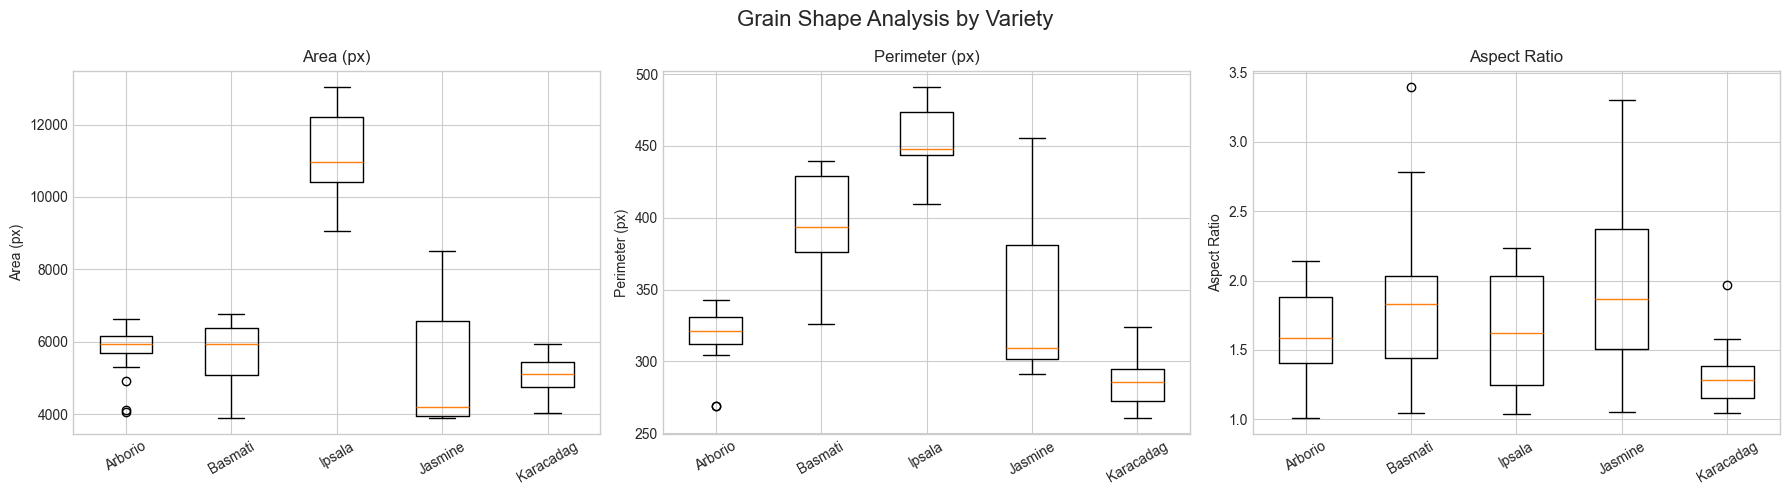

In [21]:
samples_per_class = 20
grain_results = {name: {"areas": [], "perimeters": [], "aspect_ratios": []} for name in CLASS_NAMES}

for i, name in enumerate(CLASS_NAMES):
    mask = y == i
    class_images = X[mask][:samples_per_class]

    for img in class_images:
        gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_BGR2GRAY)
        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours:
            largest = max(contours, key=cv2.contourArea)
            area = cv2.contourArea(largest)
            perimeter = cv2.arcLength(largest, True)
            x_pos, y_pos, w, h = cv2.boundingRect(largest)
            aspect_ratio = max(w, h) / (min(w, h) + 1e-8)

            grain_results[name]["areas"].append(area)
            grain_results[name]["perimeters"].append(perimeter)
            grain_results[name]["aspect_ratios"].append(aspect_ratio)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Grain Shape Analysis by Variety", fontsize=16)

metrics = [("areas", "Area (px)"), ("perimeters", "Perimeter (px)"), ("aspect_ratios", "Aspect Ratio")]
for ax, (key, ylabel) in zip(axes, metrics):
    data = [grain_results[name][key] for name in CLASS_NAMES]
    ax.boxplot(data, labels=CLASS_NAMES)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("grain_shapes.png", dpi=100)
plt.show()